# TCCP - Trustworthy customer churn prediction

This guide explains the complete assignment in plain language. Run the notebooks in this order:

1. **01_data_cleaning** - clean the raw Kaggle file and create useful features.
2. **02_model_training** - train a probability model and save its predictions.
3. **03_calibration** - check whether predicted probabilities match reality.
4. **04_shap_analysis** - explain which variables influence model predictions.
5. **05_retention_simulation** - choose customers under a fixed budget.

The business question is not only *who is likely to churn?* It is *who should receive a retention offer when money is limited?*

## Step 1 - Understand the data

The target is `Churn`. A value of 1 means the customer churned and 0 means the customer stayed. We remove `customerID` because it is an identifier, not a meaningful customer behavior. Blank `TotalCharges` values are converted to zero for brand-new customers.

In [12]:
from pathlib import Path
from scipy.stats import loguniform, randint, uniform
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Make the reusable PyTorch estimator importable from notebooks/.
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.torch_mlp import TorchMLPClassifier

models = {
    'Logistic regression': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(
                penalty='elasticnet', solver='saga', max_iter=3000,
                class_weight='balanced', random_state=SEED,
            )),
        ]),
        {'model__C': loguniform(1e-4, 1e4), 'model__l1_ratio': uniform(0, 1)},
    ),
    'SVC (RBF)': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', SVC(
                kernel='rbf', probability=True, class_weight='balanced',
                random_state=SEED,
            )),
        ]),
        {'model__C': loguniform(1e2, 1e3), 'model__gamma': loguniform(1e-4, 1)},
    ),
    'Random forest': (
        RandomForestClassifier(
            class_weight='balanced', random_state=SEED, n_jobs=-1,
        ),
        {
            'n_estimators': randint(300, 501),
            'max_depth': randint(5, 41),
            'min_samples_leaf': randint(1, 11),
        },
    ),
    'XGBoost': ( 
        XGBClassifier(
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', random_state=SEED, n_jobs=-1,
        ),
        {
            'n_estimators': randint(200, 301),
            'learning_rate': loguniform(.01, .30),
            'max_depth': randint(3, 11),
            'min_child_weight': randint(1, 11),
        },
    ),
    'Neural network (PyTorch MLP)': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', TorchMLPClassifier(
                batch_size=256, epochs=100, patience=12,
                random_state=SEED, device='cpu',
            )),
        ]),
        {
            'model__hidden_layer_sizes': [(128,), (256,), (128, 64)],
            'model__alpha': loguniform(1e-5, 1e-2),
            'model__learning_rate_init': loguniform(1e-4, 1e-2),
        },
    ),
}
print('Five model pipelines are ready.')

Five model pipelines are ready.


C:\Users\mikil\AppData\Local\Temp\ipykernel_2084\2544959216.py:10: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = counts.plot(kind='bar', color=['#4C78A8', '#F58518'], figsize=(6, 4))


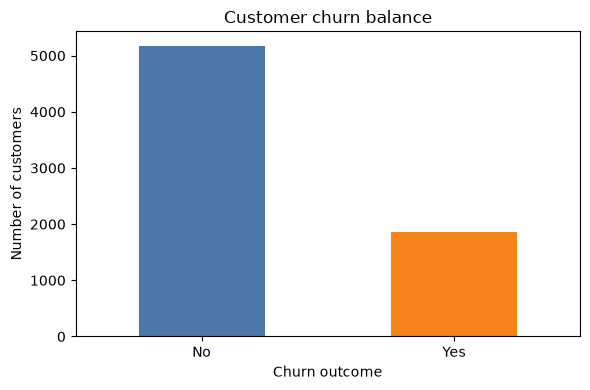

Overall churn rate: 0.2653698707936959


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw = pd.read_csv(ROOT / 'data' / 'telco.csv')

# A class-balance chart tells us how common churn is before modeling.
counts = raw['Churn'].value_counts().reindex(['No', 'Yes'])
ax = counts.plot(kind='bar', color=['#4C78A8', '#F58518'], figsize=(6, 4))
ax.set_title('Customer churn balance')
ax.set_xlabel('Churn outcome')
ax.set_ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Overall churn rate:', (raw['Churn'] == 'Yes').mean())

## Step 2 - Inspect risk patterns

These plots are descriptive, not causal. They help us understand whether churn appears different across tenure and contract groups.

C:\Users\mikil\AppData\Local\Temp\ipykernel_2084\388987863.py:5: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  contract_rate.plot(kind='bar', ax=axes[0], color='#54A24B')


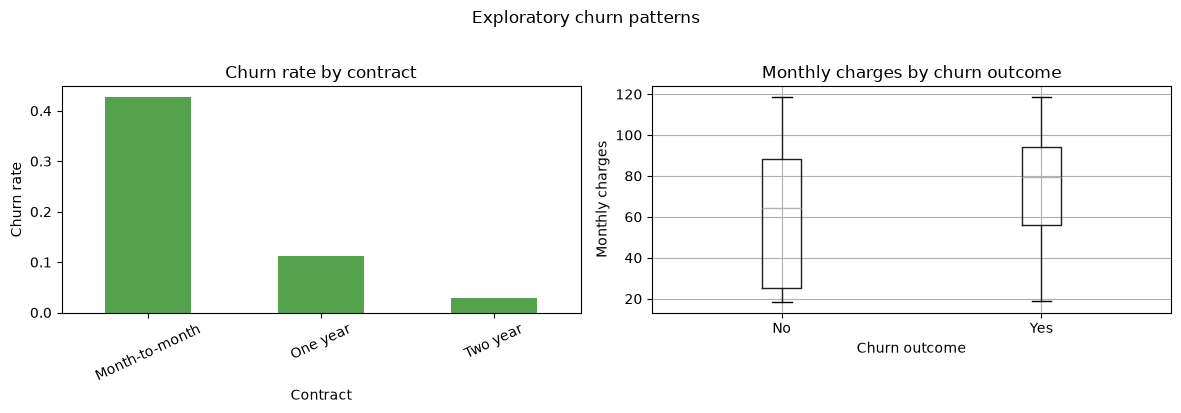

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: churn rate by contract type.
contract_rate = raw.groupby('Contract', observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean())
contract_rate.plot(kind='bar', ax=axes[0], color='#54A24B')
axes[0].set_title('Churn rate by contract')
axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=25)

# Plot 2: monthly-charge distributions for customers who stayed or churned.
raw.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly charges by churn outcome')
axes[1].set_xlabel('Churn outcome')
axes[1].set_ylabel('Monthly charges')
fig.suptitle('Exploratory churn patterns', y=1.02)
plt.tight_layout()
plt.show()

## Step 3 - Evaluate trustworthy probabilities

ROC-AUC measures ranking quality, but it does not tell us whether a prediction of 0.70 really means that about 70% of similar customers churn. The Brier score measures probability error; lower is better. The calibration curve compares predicted risk with observed churn.

In [15]:
# Run 03_calibration.ipynb after 02_model_training.ipynb.
# The notebook saves figures/calibration_curve.png for the final report.
from IPython.display import Markdown
display(Markdown('Open **03_calibration.ipynb** next. A curve close to the diagonal is desirable.'))

Open **03_calibration.ipynb** next. A curve close to the diagonal is desirable.

## Step 4 - Explain and make the decision

SHAP values show how each feature moves an individual prediction higher or lower. They describe the model's reasoning and should not be reported as proof that a feature causes churn.

For targeting, we rank customers by predicted churn probability. Under a budget, we contact only the top-k customers. Expected net value is: `probability x save rate x customer value - contact cost`. The save rate is an assumption and should eventually be estimated with an experiment.